In [1]:
import pandas as pd
import sys
sys.path.append('..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.core.ablation_trainer import AblationTrainer

In [3]:
# Models đại diện cho ablation
from src.model.random_forest_classifier import RandomForestClassifierModel
from src.model.xgb_classifier import XGBClassifierModel
from src.model.xgbrf_classifier import XGBRFClassifierModel
from src.model.hist_gradient_boosting_classifier import HistGradientBoostingClassifierModel
from src.model.ridge_regression import RidgeRegressionModel
from src.model.lasso_regression import LassoRegressionModel
from src.model.svm_classifier import SVMClassifierModel


RANDOM_STATE = 42
RESULTS_DIR  = Path('../results/ablation')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done!")

Setup done!


In [4]:
# ================================================================== #
# CELL 2 — Load Data
# ================================================================== #

# Processed data — dùng cho Ablation 1 và 3
train_tree   = pd.read_csv('../data/processed/tree/train.csv')
train_linear = pd.read_csv('../data/processed/linear/train.csv')
test_tree    = pd.read_csv('../data/processed/tree/test.csv')
test_linear  = pd.read_csv('../data/processed/linear/test.csv')

# Raw train — dùng cho Ablation 2 (preprocessor chạy lại)
raw_train = pd.read_csv('../data/splits/train.csv')

print(f"train_tree   : {train_tree.shape}")
print(f"train_linear : {train_linear.shape}")
print(f"raw_train    : {raw_train.shape}")
print(f"\nClass distribution (train_tree):")
print(train_tree['risk_class'].value_counts())

train_tree   : (2370, 18)
train_linear : (2370, 38)
raw_train    : (2370, 18)

Class distribution (train_tree):
risk_class
Low       1595
Medium     459
High       316
Name: count, dtype: int64


In [5]:
ablation = AblationTrainer(
    n_splits=5, n_repeats=3, random_state=RANDOM_STATE
)
MODELS = {
    'RF'    : RandomForestClassifierModel(),
    'XGB'   : XGBClassifierModel(),
    'Ridge' : RidgeRegressionModel(),
    'SVM'   : SVMClassifierModel()
}

print("AblationTrainer initialized!")
print(f"CV: {ablation.n_splits} folds × {ablation.n_repeats} repeats "
      f"= {ablation.n_splits * ablation.n_repeats} scores per config")

AblationTrainer initialized!
CV: 5 folds × 3 repeats = 15 scores per config


In [6]:
# ================================================================== #
# CELL 4 — ABLATION 1: Imbalance Handling
# ================================================================== #
print("\n" + "="*60)
print("ABLATION 1: SMOTE vs No SMOTE")
print("="*60)
print("""
Mục đích: Chứng minh SMOTE cần thiết với dataset imbalanced (5x)
Models  : RF (tree), Ridge (linear)
Data    : train_tree cho RF/XGB, train_linear cho Ridge
""")

results_imbalance = ablation.run_ablation_imbalance(
    train_tree   = train_tree,
    train_linear = train_linear,
    models       = {
        'RF'   : RandomForestClassifierModel(),
        'RIDGE': RidgeRegressionModel(),
        'Lasso' : LassoRegressionModel(),
        'XGBRF': XGBRFClassifierModel(),
        'HitsGB': HistGradientBoostingClassifierModel(),
        'SVM': SVMClassifierModel()
    }
)




ABLATION 1: SMOTE vs No SMOTE

Mục đích: Chứng minh SMOTE cần thiết với dataset imbalanced (5x)
Models  : RF (tree), Ridge (linear)
Data    : train_tree cho RF/XGB, train_linear cho Ridge


ABLATION 1 — Imbalance Handling
      CV F2  : 0.8451 ± 0.0229
      F1w    : 0.9098
      Gap    : 0.1549 ⚠️ overfit
      CV F2  : 0.8483 ± 0.0191
      F1w    : 0.9011
      Gap    : 0.1517 ⚠️ overfit
      CV F2  : 0.5421 ± 0.0244
      F1w    : 0.6086
      Gap    : 0.0119 ✅
      CV F2  : 0.5138 ± 0.0209
      F1w    : 0.5210
      Gap    : 0.0120 ✅
      CV F2  : 0.3970 ± 0.0506
      F1w    : 0.5463
      Gap    : 0.0101 ✅
      CV F2  : 0.3887 ± 0.0578
      F1w    : 0.4282
      Gap    : 0.0042 ✅
      CV F2  : 0.8565 ± 0.0187
      F1w    : 0.9119
      Gap    : 0.0798 ✅
      CV F2  : 0.8938 ± 0.0149
      F1w    : 0.9176
      Gap    : 0.0724 ✅
      CV F2  : 0.8968 ± 0.0149
      F1w    : 0.9256
      Gap    : 0.1032 ⚠️ overfit
      CV F2  : 0.8937 ± 0.0152
      F1w    : 0.9236
    

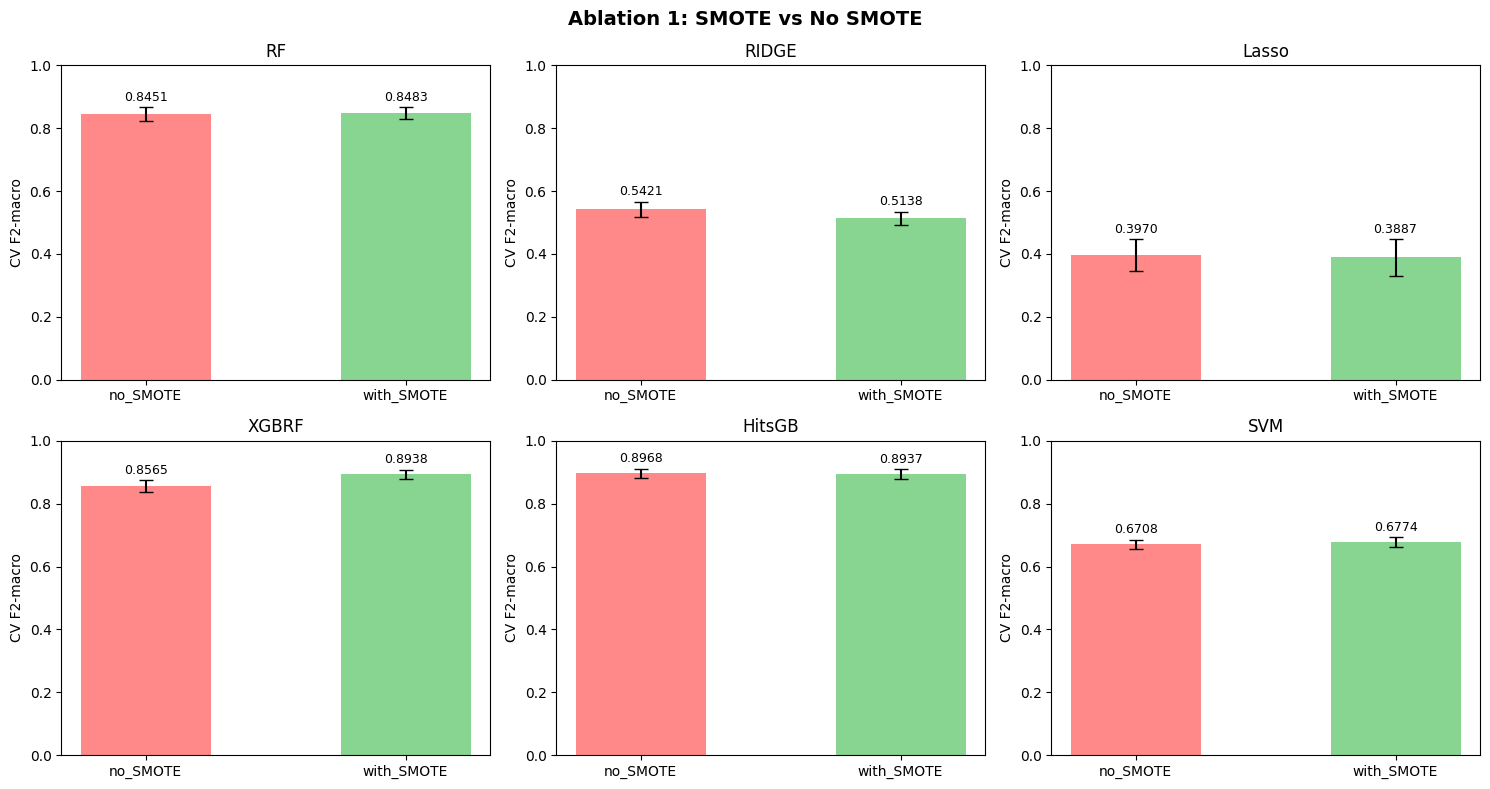

In [12]:
df_imbalance = ablation.to_dataframe()
df_imbalance = df_imbalance[df_imbalance['experiment'] == 'imbalance']

models = ['RF', 'RIDGE','Lasso' ,'XGBRF', 'HitsGB', 'SVM']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

fig.suptitle('Ablation 1: SMOTE vs No SMOTE',
             fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, models):

    sub = df_imbalance[df_imbalance['model'] == model_name]

    if sub.empty:
        ax.set_visible(False)
        continue

    colors = [
        '#FF6B6B' if 'no' in c.lower()
        else '#6BCB77'
        for c in sub['config']
    ]

    bars = ax.bar(
        sub['config'],
        sub['cv_f2_mean'],
        yerr=sub['cv_f2_std'],
        color=colors,
        alpha=0.8,
        capsize=5,
        width=0.5
    )

    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('CV F2-macro')
    ax.set_ylim(0, 1)

    for bar, mean, std in zip(
        bars,
        sub['cv_f2_mean'],
        sub['cv_f2_std']
    ):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.01,
            f'{mean:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Hide unused subplot
for i in range(len(models), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / 'ablation1_imbalance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

In [8]:
# ================================================================== #
# CELL 6 — ABLATION 2: Feature Engineering
# ================================================================== #
print("\n" + "="*60)
print("ABLATION 2: Feature Engineering Groups")
print("="*60)
print("""
Mục đích: Tìm group features nào đóng góp nhiều nhất
Configs :
  baseline → chỉ 5 numeric gốc + categorical
  +G1      → + G1_infra_vuln
  +G2      → + G2_rain_x_return
  +G3      → + G3_soil_x_rainfall
  +G4      → + G4_is_very_low_elev
  ALL      → tất cả G1+G2+G3+G4
Models  : RF, XGB, Ridge
Data    : raw_train (preprocessor chạy lại cho từng config)
""")

results_features = ablation.run_ablation_features(
    raw_train_df = raw_train,
    models       = {
        'RF'   : RandomForestClassifierModel(),
        'XGB'  : XGBClassifierModel(),
        'Ridge': RidgeRegressionModel(),
        'Lasso': LassoRegressionModel(),
        'SVM'   : SVMClassifierModel()
    }
)


ABLATION 2: Feature Engineering Groups

Mục đích: Tìm group features nào đóng góp nhiều nhất
Configs :
  baseline → chỉ 5 numeric gốc + categorical
  +G1      → + G1_infra_vuln
  +G2      → + G2_rain_x_return
  +G3      → + G3_soil_x_rainfall
  +G4      → + G4_is_very_low_elev
  ALL      → tất cả G1+G2+G3+G4
Models  : RF, XGB, Ridge
Data    : raw_train (preprocessor chạy lại cho từng config)


ABLATION 2 — Feature Engineering

  Config: baseline — groups=[]
[PipelineA] fitting on 2,370 rows, fe_groups=[]...
[PipelineA] done — 10 features
      CV F2  : 0.8630 ± 0.0209
      F1w    : 0.9092
      Gap    : 0.1370 ⚠️ overfit
[PipelineA] fitting on 2,370 rows, fe_groups=[]...
[PipelineA] done — 10 features
      CV F2  : 0.8835 ± 0.0166
      F1w    : 0.9182
      Gap    : 0.1165 ⚠️ overfit

[PipelineB] fitting on 2,370 rows...
  use_skew=True, use_scale=True, use_ohe=True, fe_groups=[]
  Yeo-Johnson transforms:
    'elevation_m': skew=1.788 → λ=0.4047
    'storm_drain_proximity_m': skew=

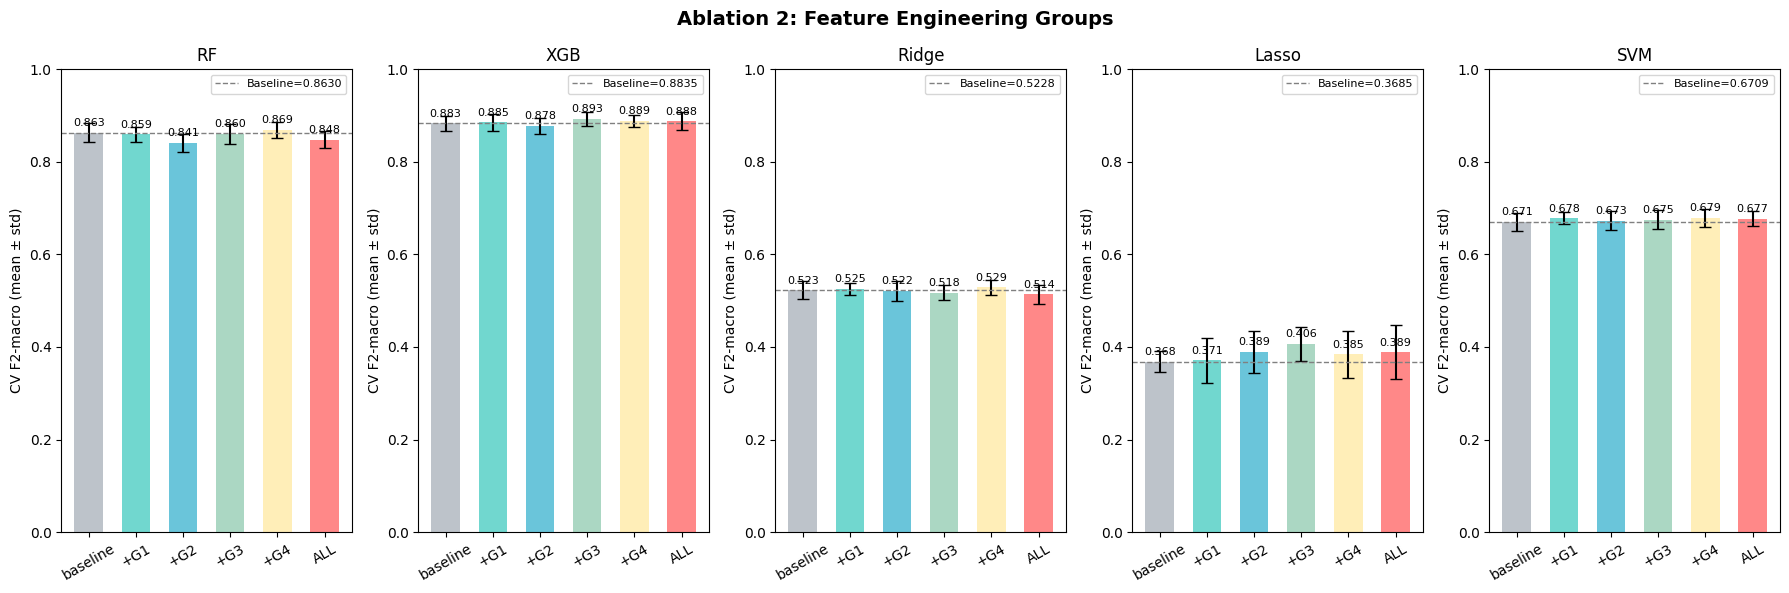


Ablation 2 Summary:
  config model  cv_f2_mean  cv_f2_std  n_features
     +G3 Lasso      0.4064     0.0366          31
     +G2 Lasso      0.3893     0.0452          31
     ALL Lasso      0.3887     0.0578          34
     +G4 Lasso      0.3845     0.0505          31
     +G1 Lasso      0.3712     0.0483          31
baseline Lasso      0.3685     0.0228          30
     +G4    RF      0.8689     0.0183          11
baseline    RF      0.8630     0.0209          10
     +G3    RF      0.8601     0.0222          11
     +G1    RF      0.8593     0.0153          11
     ALL    RF      0.8483     0.0191          14
     +G2    RF      0.8406     0.0195          11
     +G4 Ridge      0.5291     0.0163          31
     +G1 Ridge      0.5254     0.0139          31
baseline Ridge      0.5228     0.0190          30
     +G2 Ridge      0.5217     0.0217          31
     +G3 Ridge      0.5176     0.0171          31
     ALL Ridge      0.5138     0.0209          34
     +G4   SVM      0.6791   

In [11]:
# ================================================================== #
# CELL 7 — Visualize Ablation 2
# ================================================================== #
df_features = ablation.to_dataframe()
df_features = df_features[df_features['experiment'] == 'feature_engineering']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Ablation 2: Feature Engineering Groups', fontsize=14, fontweight='bold')

configs_order = ['baseline', '+G1', '+G2', '+G3', '+G4', 'ALL']
colors = ['#ADB5BD', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#FF6B6B']

for ax, model_name in zip(axes, ['RF', 'XGB', 'Ridge','Lasso','SVM']):
    sub = df_features[df_features['model'] == model_name]
    sub = sub.set_index('config').reindex(configs_order).reset_index()

    bars = ax.bar(
        sub['config'], sub['cv_f2_mean'],
        yerr=sub['cv_f2_std'],
        color=colors, alpha=0.8,
        capsize=4, width=0.6
    )
    # Đường baseline để so sánh
    baseline_val = sub[sub['config'] == 'baseline']['cv_f2_mean'].values[0]
    ax.axhline(baseline_val, color='gray', linestyle='--',
               linewidth=1, label=f'Baseline={baseline_val:.4f}')

    ax.set_title(f'{model_name}', fontsize=12)
    ax.set_ylabel('CV F2-macro (mean ± std)')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    # Annotate values
    for bar, mean in zip(bars, sub['cv_f2_mean']):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation2_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nAblation 2 Summary:")
print(df_features[[
    'config', 'model', 'cv_f2_mean', 'cv_f2_std', 'n_features'
]].sort_values(['model', 'cv_f2_mean'], ascending=[True, False]).to_string(index=False))

In [13]:
# ================================================================== #
# CELL — ABLATION 3: Preprocessing Steps (thay thế cell cũ)
# ================================================================== #
print("\n" + "="*60)
print("ABLATION 3: Preprocessing Steps")
print("="*60)
print("""
Mục đích: Isolate đóng góp của từng bước preprocessing
Configs :
  0: PipelineA baseline
  1: + Feature Engineering
  2: + Scale only (RobustScaler)
  3: + Skew only  (Yeo-Johnson)
  4: + OHE only   (OneHotEncoder)
  5: + Scale + Skew
  6: PipelineB full (không FE)
  7: PipelineB full + FE
Models  : Ridge, SVM, RF
Data    : raw_train (preprocessor chạy lại cho từng config)
""")

from src.model.svm_classifier import SVMClassifierModel

results_preprocessing = ablation.run_ablation_preprocessing(
    raw_train_df = raw_train,
    models       = {
        'Ridge': RidgeRegressionModel(),
        'Lasso': LassoRegressionModel(),
        'SVM'  : SVMClassifierModel(),
        'RF'   : RandomForestClassifierModel(),
    }
)


ABLATION 3: Preprocessing Steps

Mục đích: Isolate đóng góp của từng bước preprocessing
Configs :
  0: PipelineA baseline
  1: + Feature Engineering
  2: + Scale only (RobustScaler)
  3: + Skew only  (Yeo-Johnson)
  4: + OHE only   (OneHotEncoder)
  5: + Scale + Skew
  6: PipelineB full (không FE)
  7: PipelineB full + FE
Models  : Ridge, SVM, RF
Data    : raw_train (preprocessor chạy lại cho từng config)


ABLATION 3 — Preprocessing Steps
  CV: 5 folds × 3 repeats

  Config: Config0_baseline
[PipelineA] fitting on 2,370 rows, fe_groups=[]...
[PipelineA] done — 10 features
    [Ridge] 10 features...
      CV F2  : 0.1449 ± 0.0006
      F1w    : 0.0314
      Gap    : 0.0000 ✅
[PipelineA] fitting on 2,370 rows, fe_groups=[]...
[PipelineA] done — 10 features
    [Lasso] 10 features...
      CV F2  : 0.1449 ± 0.0006
      F1w    : 0.0314
      Gap    : 0.0000 ✅
[PipelineA] fitting on 2,370 rows, fe_groups=[]...
[PipelineA] done — 10 features
    [SVM] 10 features...
      CV F2  : 0.5144 

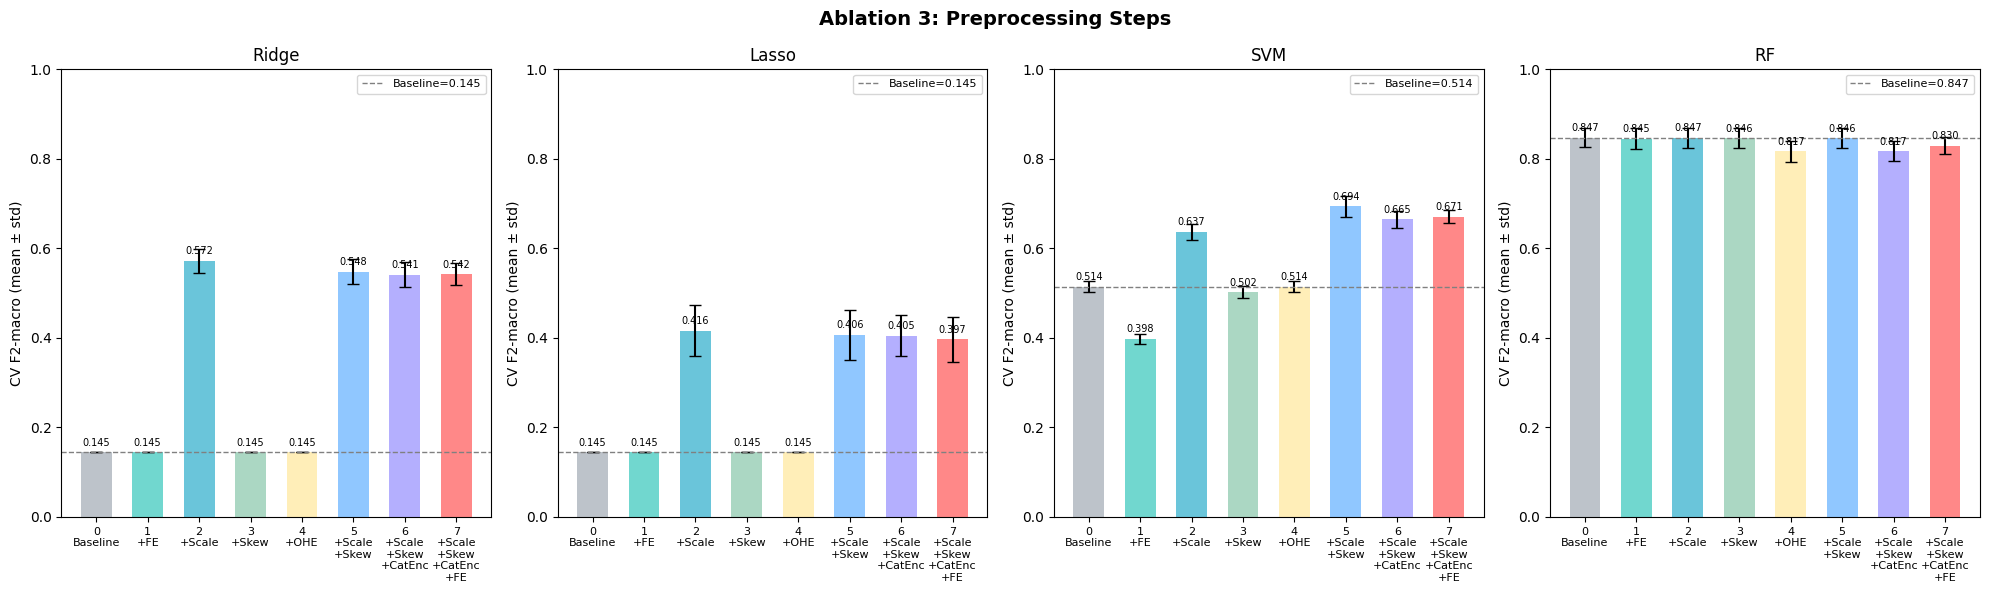


Ablation 3 Summary:


,config,model,cv_f2_mean,cv_f2_std,n_features
0,Config0_baseline,Lasso,0.1449,0.0006,10
1,Config1_+FE,Lasso,0.1449,0.0006,14
2,Config2_+Scale,Lasso,0.4161,0.0571,10
3,Config3_+Skew,Lasso,0.1449,0.0006,10
4,Config4_+OHE,Lasso,0.1449,0.0006,30
5,Config5_+Scale+Skew,Lasso,0.4065,0.0567,10
6,Config6_PipelineB_full,Lasso,0.4047,0.0454,30
7,Config7_PipelineB_full+FE,Lasso,0.3970,0.0506,34
8,Config0_baseline,RF,0.8471,0.0214,10
9,Config1_+FE,RF,0.8451,0.0229,14


In [16]:
# ── Visualize Ablation 3 ─────────────────────────────────────────
df_prep = ablation.to_dataframe()
df_prep = df_prep[df_prep['experiment'] == 'preprocessing_steps'].copy()

configs_order = [
    'Config0_baseline',
    'Config1_+FE',
    'Config2_+Scale',
    'Config3_+Skew',
    'Config4_+OHE',
    'Config5_+Scale+Skew',
    'Config6_PipelineB_full',
    'Config7_PipelineB_full+FE',
]

# Short labels cho dễ đọc
label_map = {
    'Config0_baseline'      : '0\nBaseline',
    'Config1_+FE'           : '1\n+FE',
    'Config2_+Scale'        : '2\n+Scale',
    'Config3_+Skew'         : '3\n+Skew',
    'Config4_+OHE'          : '4\n+OHE',
    'Config5_+Scale+Skew'   : '5\n+Scale\n+Skew',
    'Config6_PipelineB_full': '6\n+Scale\n+Skew\n+CatEnc',
    'Config7_PipelineB_full+FE': '7\n+Scale\n+Skew\n+CatEnc\n+FE',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Ablation 3: Preprocessing Steps', fontsize=14, fontweight='bold')

colors = ['#ADB5BD','#4ECDC4','#45B7D1','#96CEB4',
          '#FFEAA7','#74B9FF','#A29BFE','#FF6B6B']

for ax, model_name in zip(axes, ['Ridge','Lasso','SVM', 'RF']):
    sub = df_prep[df_prep['model'] == model_name]
    sub = sub.set_index('config').reindex(configs_order).reset_index()

    labels = [label_map[c] for c in sub['config']]
    bars   = ax.bar(
        range(len(labels)), sub['cv_f2_mean'],
        yerr=sub['cv_f2_std'],
        color=colors, alpha=0.8,
        capsize=4, width=0.6
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)

    # Baseline reference line
    baseline = sub[sub['config'] == 'Config0_baseline']['cv_f2_mean'].values
    if len(baseline) > 0:
        ax.axhline(baseline[0], color='gray', linestyle='--',
                   linewidth=1, label=f'Baseline={baseline[0]:.3f}')

    ax.set_title(f'{model_name}', fontsize=12)
    ax.set_ylabel('CV F2-macro (mean ± std)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    # Annotate values
    for bar, mean in zip(bars, sub['cv_f2_mean']):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=7
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation3_preprocessing.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nAblation 3 Summary:")
display(df_prep[[
    'config', 'model', 'cv_f2_mean', 'cv_f2_std', 'n_features'
]].sort_values(['model', 'config']).reset_index(drop=True))